## Lesson 6: Essay Writer

In [1]:
import os 
from dotenv import load_dotenv

load_dotenv()

gemini_api_key = os.getenv('GEMINI_API_KEY')
tavily_api_key = os.getenv('TAVILY_API_KEY')

In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_google_genai import ChatGoogleGenerativeAI

In [4]:
# Initialize the Gemini chat model
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",  # You can choose other Gemini models like "gemini-pro"
    temperature=0.7,
    max_output_tokens=2048,
    api_key=gemini_api_key
)

E0000 00:00:1760278572.745130 13371842 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [5]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
db_path = 'essay_writer_checkpoints.db'
conn = sqlite3.connect(db_path, check_same_thread=False)

memory = SqliteSaver(conn)

In [6]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int


In [7]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

In [8]:
WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

In [9]:
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

In [10]:
RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""


In [11]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""


In [12]:
from langchain_core.pydantic_v1 import BaseModel

class Queries(BaseModel):
    queries: List[str]

/Users/rishabharya/Documents/Projects/Coursera/Generative-AI-with-LLMs/.venv/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


In [13]:
from tavily import TavilyClient
tavily = TavilyClient(api_key=tavily_api_key)

In [14]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ]
    response = llm.invoke(messages)
    return {'plan': response.content}

In [15]:
def research_plan_node(state: AgentState):
    queries = llm.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    content = state.get('content', [])
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [16]:
def generation_node(state: AgentState):
    content = "\n\n".join(state.get('content', []))
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content)
        ),
        user_message
        ]
    response = llm.invoke(messages)
    return {
        "draft": response.content, 
        "revision_number": state.get("revision_number", 1) + 1
    }


In [17]:
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT), 
        HumanMessage(content=state['draft'])
    ]
    response = llm.invoke(messages)
    return {"critique": response.content}

In [18]:
def research_critique_node(state: AgentState):
    queries = llm.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])

    content = state.get('content', [])
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [19]:
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

In [20]:
builder = StateGraph(AgentState)

In [21]:
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

In [22]:
builder.set_entry_point("planner")

In [23]:
builder.add_conditional_edges(
    "generate", 
    should_continue, 
    {END: END, "reflect": "reflect"}
)


In [24]:
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [25]:
graph = builder.compile(checkpointer=memory)

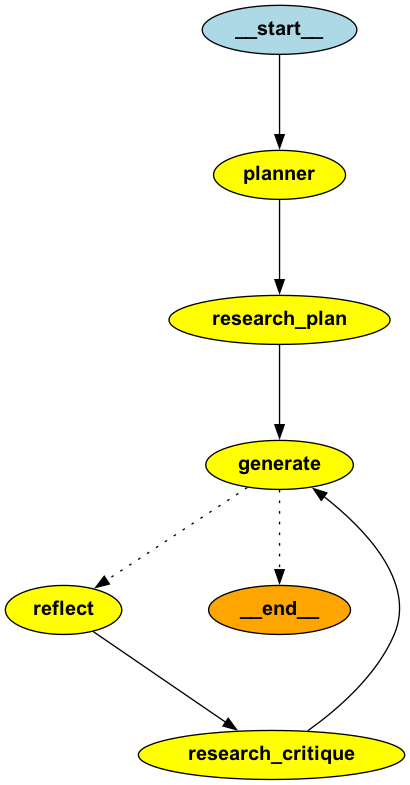

In [26]:
from IPython.display import Image

Image(graph.get_graph().draw_png())

In [27]:
thread = {"configurable": {"thread_id": "1"}}
for s in graph.stream({
    'task': "what is the difference between langchain and langsmith",
    "max_revisions": 2,
    "revision_number": 1,
}, thread):
    print(s)

{'planner': {'plan': 'Here\'s a high-level outline for an essay explaining the difference between LangChain and LangSmith, along with relevant notes and instructions for each section.\n\n---\n\n## Essay Outline: LangChain vs. LangSmith - Distinct Tools in the LLM Ecosystem\n\n**Essay Title Idea:** Building Brilliance vs. Ensuring Excellence: Understanding the Roles of LangChain and LangSmith in LLM Development\n\n---\n\n### I. Introduction\n*   **Hook:** The rapid evolution of Large Language Models (LLMs) has opened new frontiers for application development, but also introduced unique challenges in building, debugging, and maintaining these complex systems.\n*   **Context:** Introduce the LLM development landscape and the need for specialized tools.\n*   **Introduce LangChain & LangSmith:** Briefly mention both as prominent tools in this ecosystem, often confused or seen as interchangeable.\n*   **Thesis Statement:** While both are integral to the LangChain ecosystem, LangChain is a **

In [28]:
states = []
for state in graph.get_state_history(thread):
    print(state)
    print('--')
    states.append(state)

StateSnapshot(values={'task': 'what is the difference between langchain and langsmith', 'plan': 'Here\'s a high-level outline for an essay explaining the difference between LangChain and LangSmith, along with relevant notes and instructions for each section.\n\n---\n\n## Essay Outline: LangChain vs. LangSmith - Distinct Tools in the LLM Ecosystem\n\n**Essay Title Idea:** Building Brilliance vs. Ensuring Excellence: Understanding the Roles of LangChain and LangSmith in LLM Development\n\n---\n\n### I. Introduction\n*   **Hook:** The rapid evolution of Large Language Models (LLMs) has opened new frontiers for application development, but also introduced unique challenges in building, debugging, and maintaining these complex systems.\n*   **Context:** Introduce the LLM development landscape and the need for specialized tools.\n*   **Introduce LangChain & LangSmith:** Briefly mention both as prominent tools in this ecosystem, often confused or seen as interchangeable.\n*   **Thesis Stateme

In [47]:
for task in states[2].tasks:
    print(task.name)
    print(task.result)
    print('='*100)

research_critique
{'content': ['*   [Platform](https://blog.promptlayer.com/langchain-vs-langsmith/#t) *   [-- Prompt Management](https://www.promptlayer.com/platform/prompt-management) *   [-- Evaluations](https://www.promptlayer.com/platform/evaluations) ![Image 2: LangChain vs LangSmith: A Developer-Focused Comparison](https://blog.promptlayer.com/content/images/2025/05/How-a-Prompt-Engineering-Tool-Improves-AI-Model-Performance--100-.png) In LLM application development, LangChain and LangSmith have become central tools for building and managing large language model-powered solutions. This article compares LangChain and LangSmith, focusing on their core features, integration options, and value for developers in the LLM application space. LangChain is an open-source framework that helps developers create LLM applications efficiently. LangSmith provides tools to debug, monitor, and improve LLM-powered agents, and offers a managed cloud service with a web UI. | LLM Evaluation | Minimal

In [31]:
states[-2].tasks

(PregelTask(id='e8626a58-21db-4138-f299-6f6da5baca6d', name='planner', path=('__pregel_pull', 'planner'), error=None, interrupts=(), state=None, result={'plan': 'Here\'s a high-level outline for an essay explaining the difference between LangChain and LangSmith, along with relevant notes and instructions for each section.\n\n---\n\n## Essay Outline: LangChain vs. LangSmith - Distinct Tools in the LLM Ecosystem\n\n**Essay Title Idea:** Building Brilliance vs. Ensuring Excellence: Understanding the Roles of LangChain and LangSmith in LLM Development\n\n---\n\n### I. Introduction\n*   **Hook:** The rapid evolution of Large Language Models (LLMs) has opened new frontiers for application development, but also introduced unique challenges in building, debugging, and maintaining these complex systems.\n*   **Context:** Introduce the LLM development landscape and the need for specialized tools.\n*   **Introduce LangChain & LangSmith:** Briefly mention both as prominent tools in this ecosystem,

In [36]:
len(states)

8